In [0]:
# Read existing tables

stats_df = spark.table(
    "players_categorization.reclassification.player_statistics_extended"
)

players_df = spark.table(
    "players_categorization.reclassification.players"
)

print(f"Stats rows: {stats_df.count():,}")
print(f"Players rows: {players_df.count():,}")

Stats rows: 838,741
Players rows: 6,692


In [0]:
# ── Cell 2: Verify tables ──

display(spark.sql("SHOW TABLES IN players_categorization.reclassification"))

database,tableName,isTemporary
reclassification,player_statistics_extended,false
reclassification,players,false


In [0]:
"""
NBA Player Archetype Classification System
==========================================
Classifies NBA players (1996–present) by role and skill profile using
career-aggregated Regular Season and Playoff box score data.

Classification Philosophy
─────────────────────────
Minutes are the primary driver of role — they reflect how much a coaching
staff trusts and relies on a player. Points are secondary and only used
to separate Superstar from All-Star at the top tier. This intentionally
accounts for high-impact, low-scoring players like Draymond Green (Starter),
Andre Roberson (Rotation Player), and Dennis Rodman (Starter).

Role Tiers
──────────
Established (150+ career games):
  Superstar       : 27+ min, 24+ pts
  All-Star        : 27+ min, 14–24 pts
  Starter         : 22+ min
  Rotation Player : 10–22 min, 100+ games
  Bench Player    :  8–10 min, 100+ games
  End of Bench    :  <8 min,   <50 games

Developmental (under 150 games):
  Potential Starter : 27+ min  → starter usage, career interrupted or too early
  Prospect          : 10–27 min → on a trajectory, insufficient sample
  Developing        : ≤10 min  → limited role, still establishing themselves

Skill Labels (per position group, Regular Season and Playoffs independently)
─────────────────────────────────────────────────────────────────────────────
Per-36 metrics (Pts/Reb/Ast) are ranked within Guard / Forward / Center pools
so players are only compared to peers at their position.

Minimum pool thresholds:
  Regular Season : 500+ total minutes, 40+ games
  Playoffs       : 100+ total minutes, 10+ games

Percentile → Label mapping (same for Scoring, Rebounding, Playmaking):
  ≥95th  → Elite
  ≥80th  → Great
  ≥60th  → Good
  ≥30th  → Average
  <30th  → Limited

Databricks Tables
─────────────────
  players_categorization.reclassification.player_statistics_extended
  players_categorization.reclassification.players

Output
──────
  player_archetype_system.csv — one row per player per season type (RS + Playoffs)
"""

import pandas as pd
import numpy as np

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
RS_MIN_MINUTES = 500
RS_MIN_GAMES   = 40
PO_MIN_MINUTES = 100
PO_MIN_GAMES   = 10

# ─────────────────────────────────────────────
# 1. LOAD
# ─────────────────────────────────────────────
print("Loading data...")
stats        = spark.table("players_categorization.reclassification.player_statistics_extended").toPandas()
players_meta = spark.table("players_categorization.reclassification.players").toPandas()

# ─────────────────────────────────────────────
# 2. PREP & FILTER
# ─────────────────────────────────────────────
for col in ["numMinutes", "points", "assists", "reboundsTotal"]:
    stats[col] = pd.to_numeric(stats[col], errors="coerce")

stats = stats[stats["gameType"].isin(["Regular Season", "Playoffs"])].copy()

# Canonical name per personId (most frequent name wins — handles name changes/typos)
stats["playerName"] = stats["firstName"].str.strip() + " " + stats["lastName"].str.strip()
name_map = stats.groupby("personId")["playerName"].agg(lambda x: x.mode().iloc[0])
stats["playerName"] = stats["personId"].map(name_map)

# Remove duplicate player-game records (keep first occurrence)
stats = stats.drop_duplicates(subset=["personId", "gameId"], keep="first")

# ─────────────────────────────────────────────
# 3. AGGREGATE per player per season type
# ─────────────────────────────────────────────
agg = (
    stats.groupby(["personId", "playerName", "gameType"])
    .agg(
        gamesPlayed  = ("gameId",        "nunique"),
        totalMinutes = ("numMinutes",    "sum"),
        avgMinutes   = ("numMinutes",    "mean"),
        avgPoints    = ("points",        "mean"),
        avgRebounds  = ("reboundsTotal", "mean"),
        avgAssists   = ("assists",       "mean"),
    )
    .reset_index()
)

# ─────────────────────────────────────────────
# 4. POSITION MAPPING
#    Priority: Center > Forward > Guard
#    Multi-position players inherit the "bigger" position
# ─────────────────────────────────────────────
pos_meta = players_meta[["personId", "guard", "forward", "center"]].copy()
for col in ["guard", "forward", "center"]:
    pos_meta[col] = pd.to_numeric(pos_meta[col], errors="coerce").fillna(0).astype(int)

def assign_position(row):
    if row["center"]  == 1: return "Center"
    if row["forward"] == 1: return "Forward"
    if row["guard"]   == 1: return "Guard"
    return "Unknown"

pos_meta["position"] = pos_meta.apply(assign_position, axis=1)
agg = agg.merge(pos_meta[["personId", "position"]], on="personId", how="left")
agg["position"] = agg["position"].fillna("Unknown")

# ─────────────────────────────────────────────
# 5. ROLE CLASSIFICATION  (Regular Season only)
#
#  Rule priority — first match wins (top to bottom):
#    Superstar → All-Star → Starter → Rotation → Bench →
#    End of Bench → Potential Starter → Prospect → Developing
# ─────────────────────────────────────────────
def classify_role(row):
    mins  = row["avgMinutes"]
    pts   = row["avgPoints"]
    games = row["gamesPlayed"]

    # ── Established tiers (150+ career games) ──
    if games >= 150:
        if mins >= 27 and pts >= 24: return "Superstar"       # 24+ pts threshold
        if mins >= 27 and pts >= 14: return "All-Star"         # 14+ pts threshold
        if mins >= 22:               return "Starter"

    # ── Rotation & Bench (100+ games, minutes-only — no points floor) ──
    # Defensive specialists and role players are correctly placed by minutes alone
    if 10 <= mins < 22 and games >= 100: return "Rotation Player"
    if  8 <= mins < 10 and games >= 100: return "Bench Player"

    # ── End of Bench: under 8 min, under 50 career games ──
    if mins < 8 and games < 50:          return "End of Bench"

    # ── Developmental tiers (under 150 games) ──
    # Starter-level minutes — career interrupted or player too early to commit
    if mins >= 27 and games < 150:               return "Potential Starter"

    # Rotation/near-starter minutes — on a trajectory, not enough sample yet
    # Note: Rotation Player already wins at 100–149 games (caught above)
    if 10 <= mins < 27 and games < 100:          return "Prospect"

    # 22–27 min with 100–149 games — significant sample, near threshold
    if 22 <= mins < 27 and 100 <= games < 150:   return "Prospect"

    # Everything else — limited minutes, still establishing themselves
    return "Developing"

rs_mask = agg["gameType"] == "Regular Season"
agg.loc[rs_mask, "role"] = agg[rs_mask].apply(classify_role, axis=1)

# Stamp RS role onto Playoffs rows (role identity doesn't change in playoffs)
role_map = agg[rs_mask][["personId", "role"]].rename(columns={"role": "rs_role"})
agg = agg.merge(role_map, on="personId", how="left")
agg["role"] = agg["role"].fillna(agg["rs_role"]).fillna("No Regular Season Data")
agg.drop(columns="rs_role", inplace=True)

# ─────────────────────────────────────────────
# 6. PER-36 SKILL METRICS
#    Normalizes production to a 36-minute baseline so players
#    with different minute totals can be compared fairly.
# ─────────────────────────────────────────────
agg["pts_per36"] = (agg["avgPoints"]   / agg["avgMinutes"] * 36).replace([np.inf, -np.inf], np.nan).round(2)
agg["reb_per36"] = (agg["avgRebounds"] / agg["avgMinutes"] * 36).replace([np.inf, -np.inf], np.nan).round(2)
agg["ast_per36"] = (agg["avgAssists"]  / agg["avgMinutes"] * 36).replace([np.inf, -np.inf], np.nan).round(2)

# ─────────────────────────────────────────────
# 7. PERCENTILE POOLS
#    RS and Playoffs computed independently (Option B):
#    a player is ranked against peers who also played in that context.
#    Computed within position groups — guards vs guards, etc.
# ─────────────────────────────────────────────
def compute_percentiles(df_subset, min_minutes, min_games, label):
    eligible = df_subset[
        (df_subset["totalMinutes"] >= min_minutes) &
        (df_subset["gamesPlayed"]  >= min_games) &
        (df_subset["position"]     != "Unknown")
    ].copy()

    print(f"\n{label} eligible pool: {len(eligible)} players")
    for pos in ["Guard", "Forward", "Center"]:
        print(f"  {pos}s: {(eligible['position']==pos).sum()}")

    pct_rows = []
    for position, group in eligible.groupby("position"):
        grp = group[["personId", "pts_per36", "reb_per36", "ast_per36"]].copy()
        for metric, label_col in [
            ("pts_per36", "pts_pct"),
            ("reb_per36", "reb_pct"),
            ("ast_per36", "ast_pct"),
        ]:
            valid = grp[metric].notna()
            grp.loc[valid, label_col] = grp.loc[valid, metric].rank(pct=True) * 100
        pct_rows.append(grp[["personId", "pts_pct", "reb_pct", "ast_pct"]])

    return (
        pd.concat(pct_rows, ignore_index=True)
        .drop_duplicates(subset="personId")
    )

rs_pct = compute_percentiles(
    agg[agg["gameType"] == "Regular Season"],
    min_minutes=RS_MIN_MINUTES, min_games=RS_MIN_GAMES, label="Regular Season"
)
po_pct = compute_percentiles(
    agg[agg["gameType"] == "Playoffs"],
    min_minutes=PO_MIN_MINUTES, min_games=PO_MIN_GAMES, label="Playoffs"
)

rs_pct["gameType"] = "Regular Season"
po_pct["gameType"] = "Playoffs"
all_pct = pd.concat([rs_pct, po_pct], ignore_index=True)
agg = agg.merge(all_pct, on=["personId", "gameType"], how="left")

# ─────────────────────────────────────────────
# 8. SKILL LABELS
#    Percentile → human-readable label per skill dimension
# ─────────────────────────────────────────────
def skill_label(percentile, skill):
    if pd.isna(percentile): return f"N/A {skill}"
    if percentile >= 95:    return f"Elite {skill}"
    if percentile >= 80:    return f"Great {skill}"
    if percentile >= 60:    return f"Good {skill}"
    if percentile >= 30:    return f"Average {skill}"
    return                         f"Limited {skill}"

agg["scoring_label"]    = agg["pts_pct"].apply(lambda p: skill_label(p, "Scorer"))
agg["rebounding_label"] = agg["reb_pct"].apply(lambda p: skill_label(p, "Rebounder"))
agg["playmaking_label"] = agg["ast_pct"].apply(lambda p: skill_label(p, "Playmaker"))

# ─────────────────────────────────────────────
# 9. FINAL SORT, RENAME & COLUMN ORDER
# ─────────────────────────────────────────────
agg = agg.sort_values(
    ["playerName", "gameType"],
    ascending=[True, False]   # Regular Season before Playoffs alphabetically
).reset_index(drop=True)

for col in ["avgMinutes", "avgPoints", "avgRebounds", "avgAssists"]:
    agg[col] = agg[col].round(1)
for col in ["pts_pct", "reb_pct", "ast_pct"]:
    if col in agg.columns:
        agg[col] = agg[col].round(1)

agg = agg.rename(columns={
    "gameType"          : "Season Type",
    "gamesPlayed"       : "Games Played",
    "totalMinutes"      : "Total Minutes",
    "avgMinutes"        : "Avg Minutes",
    "avgPoints"         : "Avg Points",
    "avgRebounds"       : "Avg Rebounds",
    "avgAssists"        : "Avg Assists",
    "role"              : "Role Classification",
    "position"          : "Position",
    "pts_per36"         : "Pts Per 36",
    "reb_per36"         : "Reb Per 36",
    "ast_per36"         : "Ast Per 36",
    "pts_pct"           : "Scoring Percentile",
    "reb_pct"           : "Rebounding Percentile",
    "ast_pct"           : "Playmaking Percentile",
    "scoring_label"     : "Scoring Label",
    "rebounding_label"  : "Rebounding Label",
    "playmaking_label"  : "Playmaking Label",
})

final_cols = [
    "personId", "playerName", "Position", "Season Type",
    "Games Played", "Total Minutes",
    "Avg Points", "Avg Rebounds", "Avg Assists", "Avg Minutes",
    "Pts Per 36", "Reb Per 36", "Ast Per 36",
    "Scoring Percentile", "Rebounding Percentile", "Playmaking Percentile",
    "Role Classification", "Scoring Label", "Rebounding Label", "Playmaking Label",
]
agg = agg[final_cols]

## ─────────────────────────────────────────────
# 10. SAVE TO DELTA TABLE
# ─────────────────────────────────────────────
# Convert pandas DataFrame to Spark DataFrame
result_spark = spark.createDataFrame(agg)

# Clean column names for Delta compatibility
# (spaces, slashes, and special characters are not allowed in Delta column names)
for old_col in result_spark.columns:
    new_col = (
        old_col.lower()
        .replace(" ", "_")
        .replace("%", "pct")
        .replace("/", "_")
        .replace("-", "_")
    )
    if old_col != new_col:
        result_spark = result_spark.withColumnRenamed(old_col, new_col)

# Save as Delta table — overwrite replaces existing data on re-runs
result_spark.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("players_categorization.reclassification.player_archetype_system")

print(f"\n✅ Done! {len(agg):,} rows saved")
print(f"   Unique players: {agg['playerName'].nunique():,}")
print("   Table: players_categorization.reclassification.player_archetype_system")

# ─────────────────────────────────────────────
# 11. VALIDATION SUMMARY
# ─────────────────────────────────────────────
rs = agg[agg["Season Type"] == "Regular Season"]

print("\n── Role breakdown (Regular Season) ──")
print(rs["Role Classification"].value_counts().to_string())

print("\n── Spot check: known players ──")
names = [
    "Stephen Curry", "LeBron James", "Nikola Jokic", "Luka Doncic",
    "Paolo Banchero", "Victor Wembanyama", "Cooper Flagg",
    "Josh Hart", "Draymond Green", "Andre Roberson",
    "Dennis Rodman", "Rudy Gobert",
]
cols = ["playerName", "Games Played", "Avg Points", "Avg Minutes",
        "Role Classification", "Scoring Label", "Rebounding Label", "Playmaking Label"]
spot = rs[rs["playerName"].isin(names)]
print(spot[cols].sort_values("Avg Minutes", ascending=False).to_string(index=False))

Loading data...

Regular Season eligible pool: 1900 players
  Guards: 702
  Forwards: 776
  Centers: 422

Playoffs eligible pool: 970 players
  Guards: 345
  Forwards: 389
  Centers: 236

✅ Done! 4,526 rows saved
   Unique players: 2,848
   Table: players_categorization.reclassification.player_archetype_system

── Role breakdown (Regular Season) ──
Role Classification
Rotation Player      899
End of Bench         522
Prospect             470
Starter              437
Developing           277
All-Star             178
Bench Player          32
Potential Starter     27
Superstar             17

── Spot check: known players ──
       playerName  Games Played  Avg Points  Avg Minutes Role Classification  Scoring Label  Rebounding Label  Playmaking Label
     LeBron James          1615        26.8         37.2           Superstar   Elite Scorer    Good Rebounder   Elite Playmaker
      Luka Doncic           508        29.2         34.6           Superstar   Elite Scorer   Great Rebounder   Eli

In [0]:
# ── Cell 4: Interactive Player Table ──

# Convert to Spark DataFrame for display()
output = spark.createDataFrame(agg)

# Filter to Regular Season only, sorted by Avg Points descending
# Note: column names here match the PANDAS agg DataFrame (with spaces)
rs_display = agg[agg["Season Type"] == "Regular Season"] \
               .sort_values("Avg Points", ascending=False)

display(spark.createDataFrame(rs_display))

personId,playerName,Position,Season Type,Games Played,Total Minutes,Avg Points,Avg Rebounds,Avg Assists,Avg Minutes,Pts Per 36,Reb Per 36,Ast Per 36,Scoring Percentile,Rebounding Percentile,Playmaking Percentile,Role Classification,Scoring Label,Rebounding Label,Playmaking Label
1629029,Luka Doncic,Forward,Regular Season,508,17589.02,29.2,8.5,8.2,34.6,30.4,8.86,8.56,100.0,84.2,100.0,Superstar,Elite Scorer,Great Rebounder,Elite Playmaker
203954,Joel Embiid,Center,Regular Season,486,15232.84,27.6,10.8,3.7,31.3,31.69,12.36,4.22,100.0,88.7,98.0,Superstar,Elite Scorer,Great Rebounder,Elite Playmaker
201142,Kevin Durant,Forward,Regular Season,1197,43372.25,27.1,6.9,4.4,36.2,26.94,6.83,4.36,99.7,56.5,95.1,Superstar,Elite Scorer,Average Rebounder,Elite Playmaker
2544,LeBron James,Forward,Regular Season,1615,60071.56,26.8,7.5,7.4,37.2,25.92,7.22,7.17,99.5,64.6,99.6,Superstar,Elite Scorer,Good Rebounder,Elite Playmaker
947,Allen Iverson,Guard,Regular Season,914,37153.0,26.7,3.7,6.2,40.6,23.61,3.29,5.45,97.9,18.4,65.1,Superstar,Elite Scorer,Limited Rebounder,Good Playmaker
893,Michael Jordan,Guard,Regular Season,306,11251.0,25.5,5.9,4.1,36.8,24.97,5.74,4.02,98.6,91.3,39.9,Superstar,Elite Scorer,Great Rebounder,Average Playmaker
1628983,Shai Gilgeous-Alexander,Guard,Regular Season,527,17231.36,25.3,4.7,5.3,32.7,27.82,5.19,5.84,100.0,84.5,71.5,Superstar,Elite Scorer,Great Rebounder,Good Playmaker
1629027,Trae Young,Guard,Regular Season,494,16649.83,25.1,3.5,9.8,33.7,26.8,3.7,10.44,99.7,36.3,100.0,Superstar,Elite Scorer,Average Rebounder,Elite Playmaker
203081,Damian Lillard,Guard,Regular Season,894,31968.13,25.1,4.3,6.7,35.8,25.25,4.3,6.79,99.0,62.8,87.0,Superstar,Elite Scorer,Good Rebounder,Great Playmaker
1628378,Donovan Mitchell,Guard,Regular Season,607,20254.34,25.0,4.3,4.8,33.4,27.01,4.66,5.18,99.9,73.1,60.2,Superstar,Elite Scorer,Good Rebounder,Good Playmaker


/home/spark-08548d22-63cc-4ef4-b15f-2f/.ipykernel/9673/command-5080840068352092-546200371:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=30, ha="right", fontsize=9)


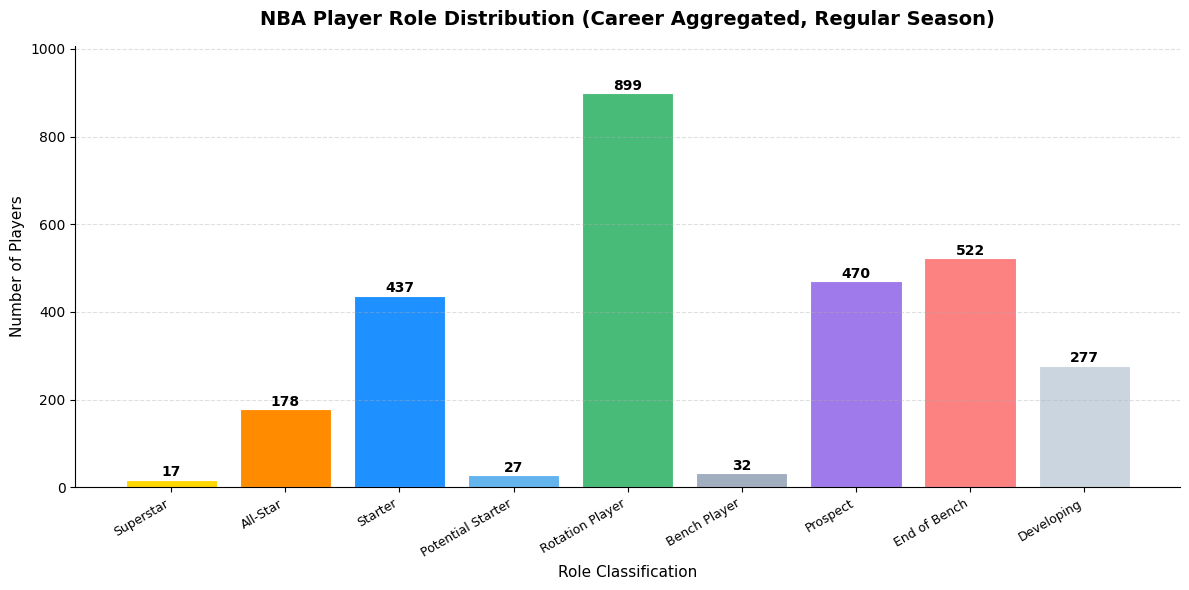

⬇ Download chart: role_distribution.png
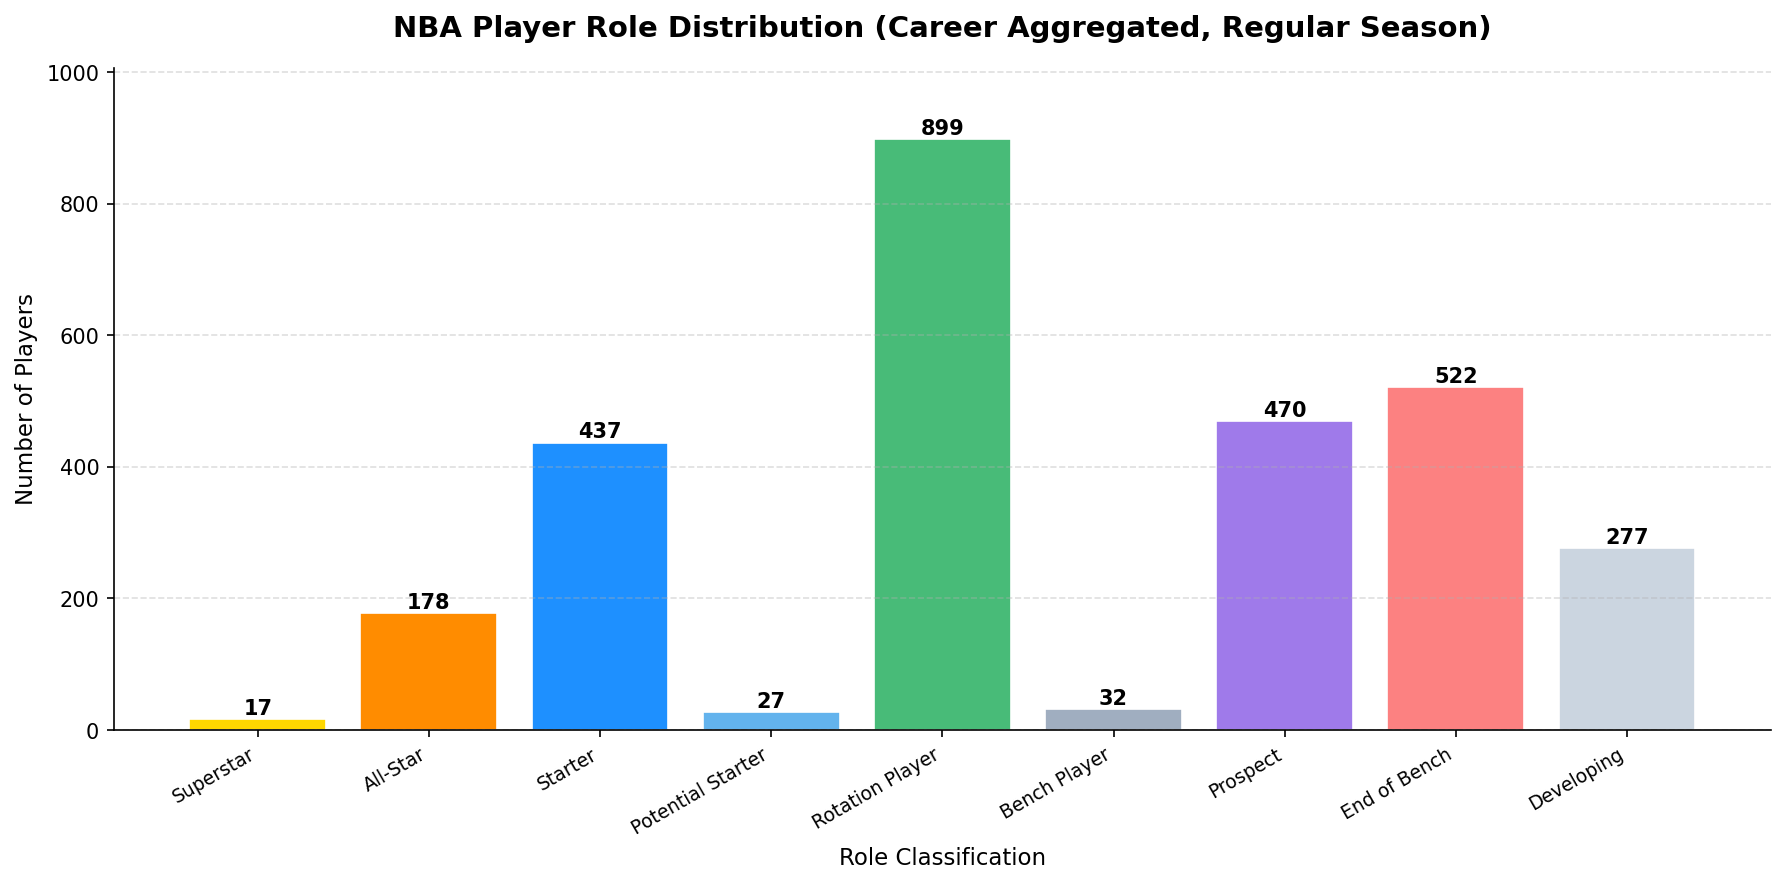

In [0]:
# ── Cell 5: Role Distribution Bar Chart ──

import matplotlib.pyplot as plt
import base64
import io

rs = agg[agg["Season Type"] == "Regular Season"].copy()

role_order = [
    "Superstar", "All-Star", "Starter", "Potential Starter",
    "Rotation Player", "Bench Player", "Prospect",
    "End of Bench", "Developing"
]
role_colors = {
    "Superstar"        : "#FFD700",
    "All-Star"         : "#FF8C00",
    "Starter"          : "#1E90FF",
    "Potential Starter": "#63B3ED",
    "Rotation Player"  : "#48BB78",
    "Bench Player"     : "#A0AEC0",
    "Prospect"         : "#9F7AEA",
    "End of Bench"     : "#FC8181",
    "Developing"       : "#CBD5E0",
}

counts = rs["Role Classification"].value_counts().reindex(role_order, fill_value=0)
colors = [role_colors.get(r, "#CBD5E0") for r in counts.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.8)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2., height + 1,
        str(int(height)), ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_title("NBA Player Role Distribution (Career Aggregated, Regular Season)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Role Classification", fontsize=11)
ax.set_ylabel("Number of Players", fontsize=11)
ax.set_xticklabels(counts.index, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, counts.max() * 1.12)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# ── Save to buffer and render download button ──
buf = io.BytesIO()
plt.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
b64 = base64.b64encode(buf.read()).decode()
plt.show()

displayHTML(f'''
  <a href="data:image/png;base64,{b64}"
     download="role_distribution.png"
     style="display:inline-block; margin-top:10px; padding:8px 16px;
            background:#1d428a; color:white; border-radius:4px;
            text-decoration:none; font-family:sans-serif;">
    ⬇ Download chart: role_distribution.png
  </a>
''')

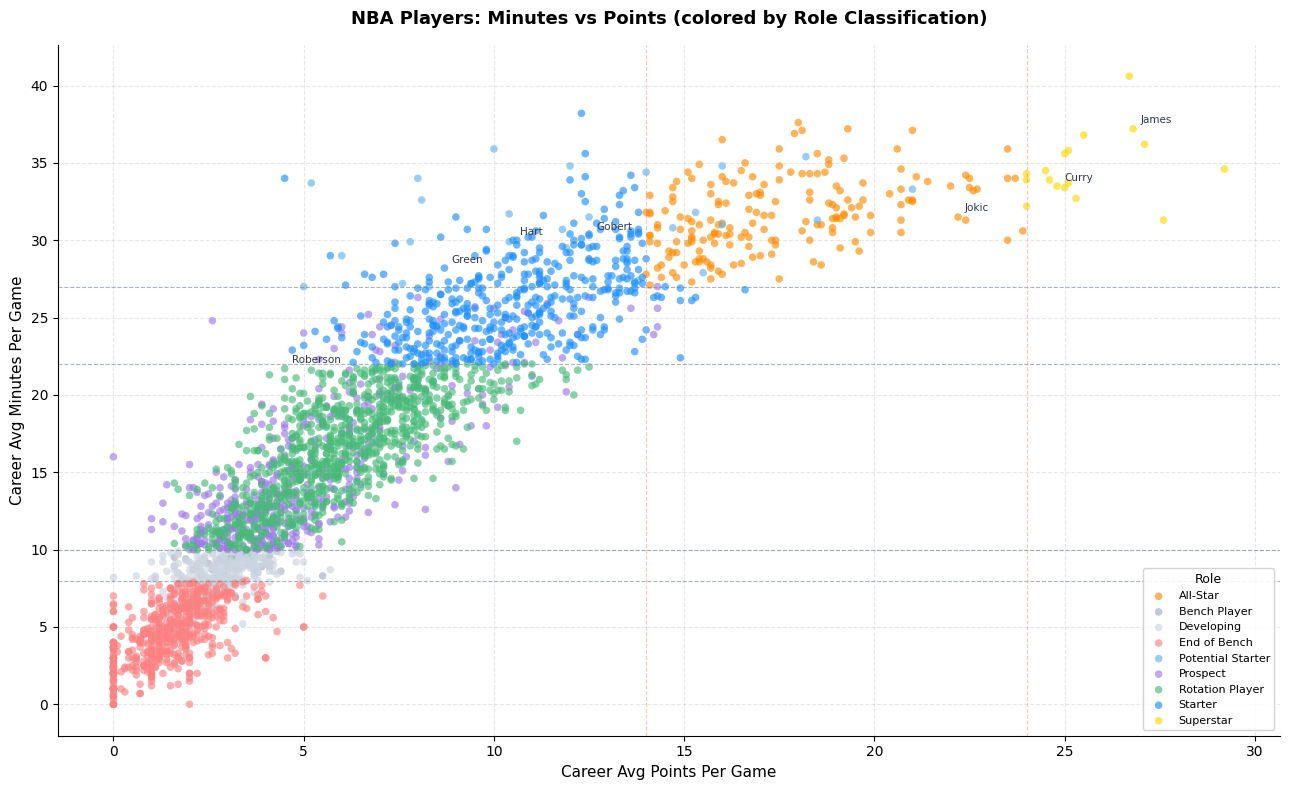

⬇ Download chart: minutes_vs_points_scatter.png
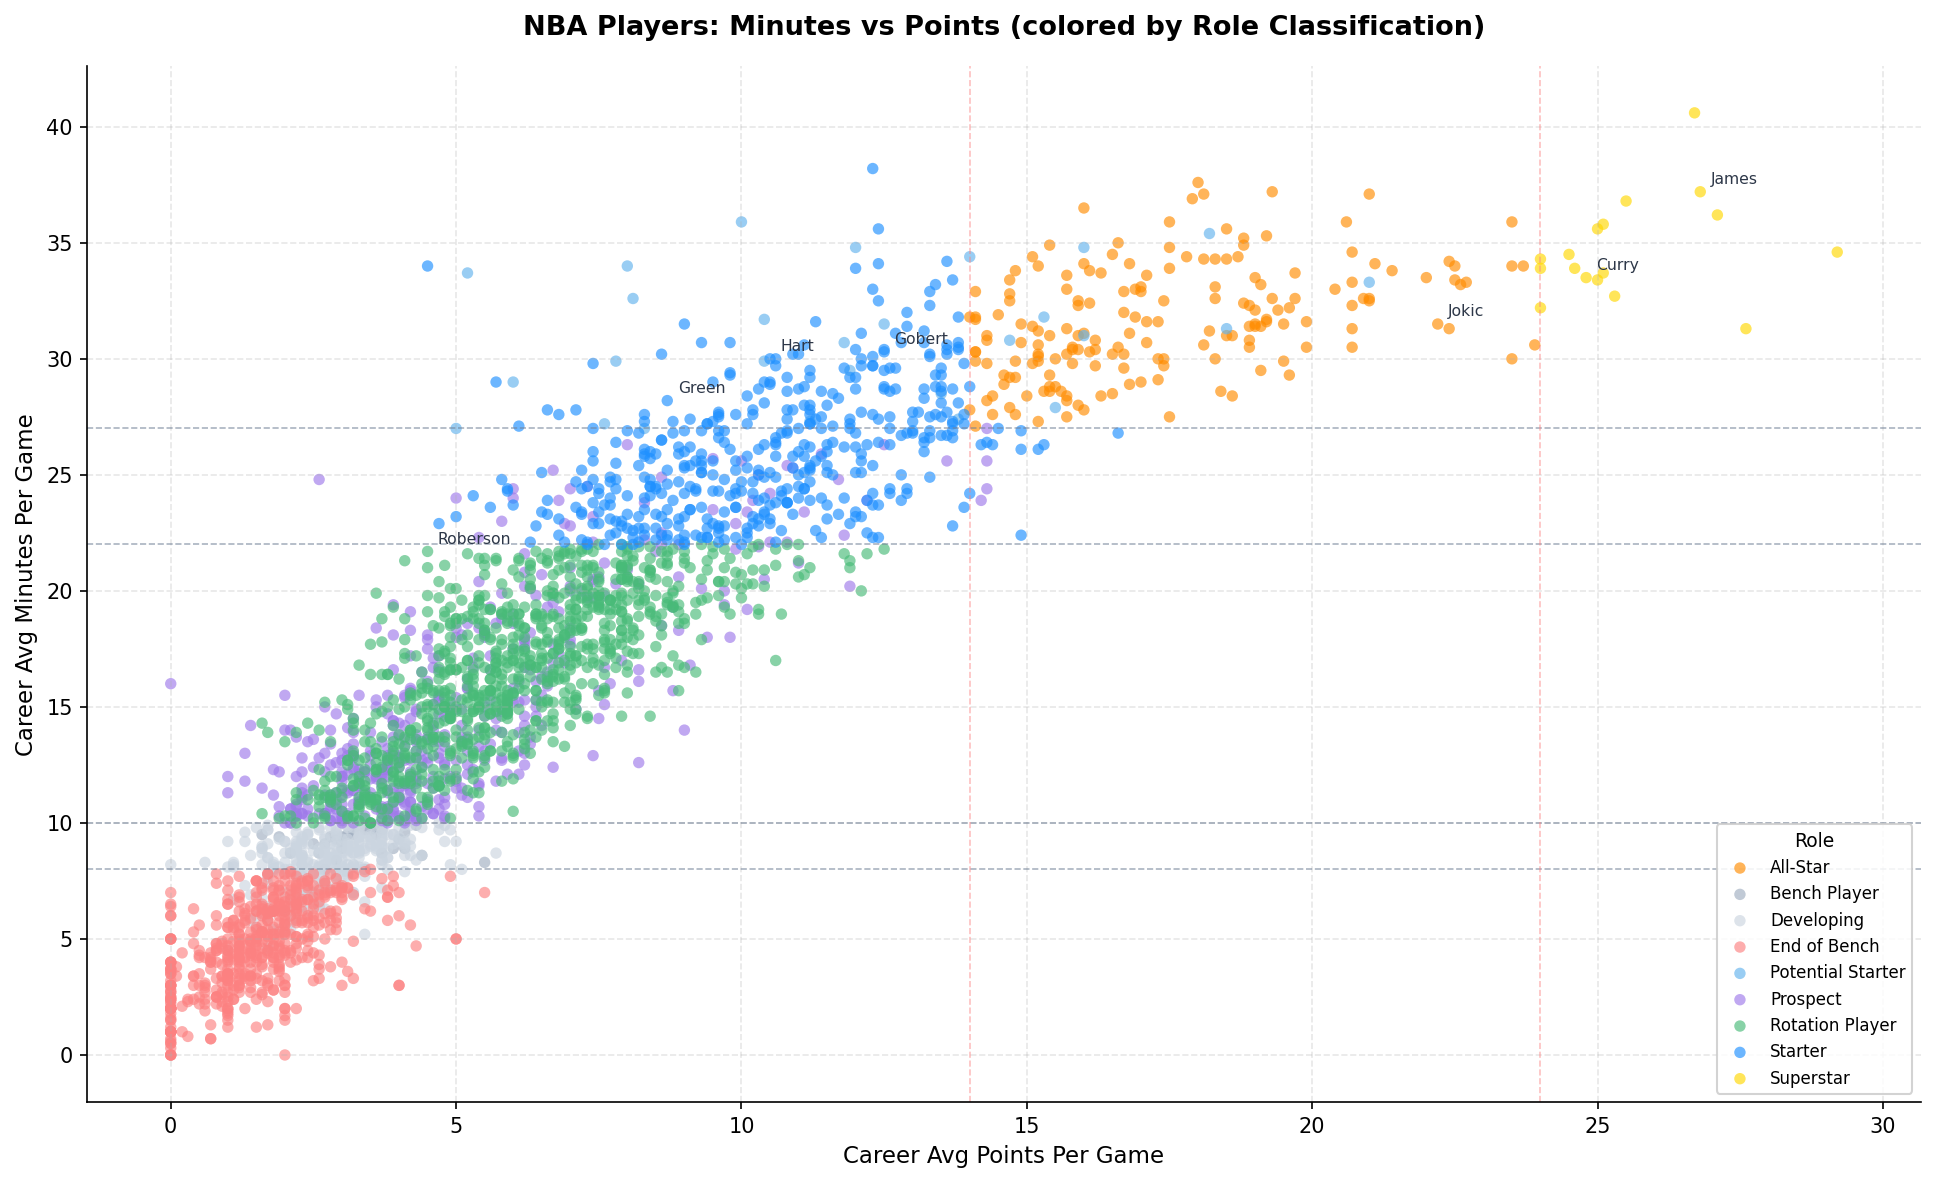

In [0]:
# ── Cell 6: Minutes vs Points Scatter Plot ──

import matplotlib.pyplot as plt
import numpy as np
import base64
import io

rs = agg[agg["Season Type"] == "Regular Season"].copy()

role_colors = {
    "Superstar"        : "#FFD700",
    "All-Star"         : "#FF8C00",
    "Starter"          : "#1E90FF",
    "Potential Starter": "#63B3ED",
    "Rotation Player"  : "#48BB78",
    "Bench Player"     : "#A0AEC0",
    "Prospect"         : "#9F7AEA",
    "End of Bench"     : "#FC8181",
    "Developing"       : "#CBD5E0",
}

fig, ax = plt.subplots(figsize=(13, 8))

for role, group in rs.groupby("Role Classification"):
    color = role_colors.get(role, "#CBD5E0")
    ax.scatter(
        group["Avg Points"], group["Avg Minutes"],
        c=color, label=role, alpha=0.65, s=30, edgecolors="none"
    )

# Annotate key players
highlight = ["LeBron James", "Stephen Curry", "Nikola Jokic",
             "Draymond Green", "Josh Hart", "Rudy Gobert", "Andre Roberson"]
for _, row in rs[rs["playerName"].isin(highlight)].iterrows():
    ax.annotate(
        row["playerName"].split()[-1],
        (row["Avg Points"], row["Avg Minutes"]),
        textcoords="offset points", xytext=(5, 4),
        fontsize=7.5, color="#2D3748"
    )

# Classification boundary reference lines
ax.axhline(y=27, color="#718096", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(y=22, color="#718096", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(y=10, color="#718096", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(y=8,  color="#718096", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axvline(x=24, color="#FC8181", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axvline(x=14, color="#FC8181", linestyle="--", linewidth=0.8, alpha=0.5)

ax.set_xlabel("Career Avg Points Per Game", fontsize=11)
ax.set_ylabel("Career Avg Minutes Per Game", fontsize=11)
ax.set_title("NBA Players: Minutes vs Points (colored by Role Classification)",
             fontsize=13, fontweight="bold", pad=15)
ax.legend(loc="lower right", fontsize=8, framealpha=0.85,
          title="Role", title_fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(linestyle="--", alpha=0.3)

plt.tight_layout()

# ── Save to buffer and render download button ──
buf = io.BytesIO()
plt.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
b64 = base64.b64encode(buf.read()).decode()
plt.show()

displayHTML(f'''
  <a href="data:image/png;base64,{b64}"
     download="minutes_vs_points_scatter.png"
     style="display:inline-block; margin-top:10px; padding:8px 16px;
            background:#1d428a; color:white; border-radius:4px;
            text-decoration:none; font-family:sans-serif;">
    ⬇ Download chart: minutes_vs_points_scatter.png
  </a>
''')

═════════════════════════════════════════════════════════════════
TOP 15 PLAYOFF ELEVATORS (Scoring Percentile)
═════════════════════════════════════════════════════════════════


playerName,Role Classification,Scoring Percentile_RS,Scoring Percentile_PO,Scoring Delta
David Wingate,Rotation Player,8.4,75.6,67.2
Al-Farouq Aminu,Starter,20.7,62.5,41.8
Jerome James,Rotation Player,36.7,77.1,40.4
T.J. McConnell,Rotation Player,46.1,84.3,38.2
Festus Ezeli,Rotation Player,27.4,65.0,37.6
Wes Iwundu,Rotation Player,8.2,43.7,35.5
Maurice Harkless,Starter,21.5,56.4,34.9
Scott Williams,Rotation Player,31.8,65.0,33.2
Caleb Martin,Starter,34.9,67.5,32.6
Darko Milicic,Rotation Player,36.5,69.1,32.6


═════════════════════════════════════════════════════════════════
TOP 15 PLAYOFF SHRINKERS (Scoring Percentile)
═════════════════════════════════════════════════════════════════


playerName,Role Classification,Scoring Percentile_RS,Scoring Percentile_PO,Scoring Delta
Trey Murphy III,All-Star,92.9,14.4,-78.5
Ryan Anderson,Starter,85.8,19.4,-66.4
Cole Anthony,Starter,87.6,22.0,-65.6
Doug McDermott,Rotation Player,79.0,15.7,-63.3
Quentin Grimes,Starter,67.7,5.8,-61.9
Dion Waiters,Starter,78.9,21.4,-57.5
Steve Novak,Rotation Player,61.6,4.6,-57.0
Damion Lee,Rotation Player,64.2,8.2,-56.0
Anfernee Simons,Starter,93.7,42.0,-51.7
Jordan Hill,Rotation Player,71.7,21.2,-50.5


<Figure size 640x480 with 0 Axes>

⬇ Download chart: playoff_elevators.png
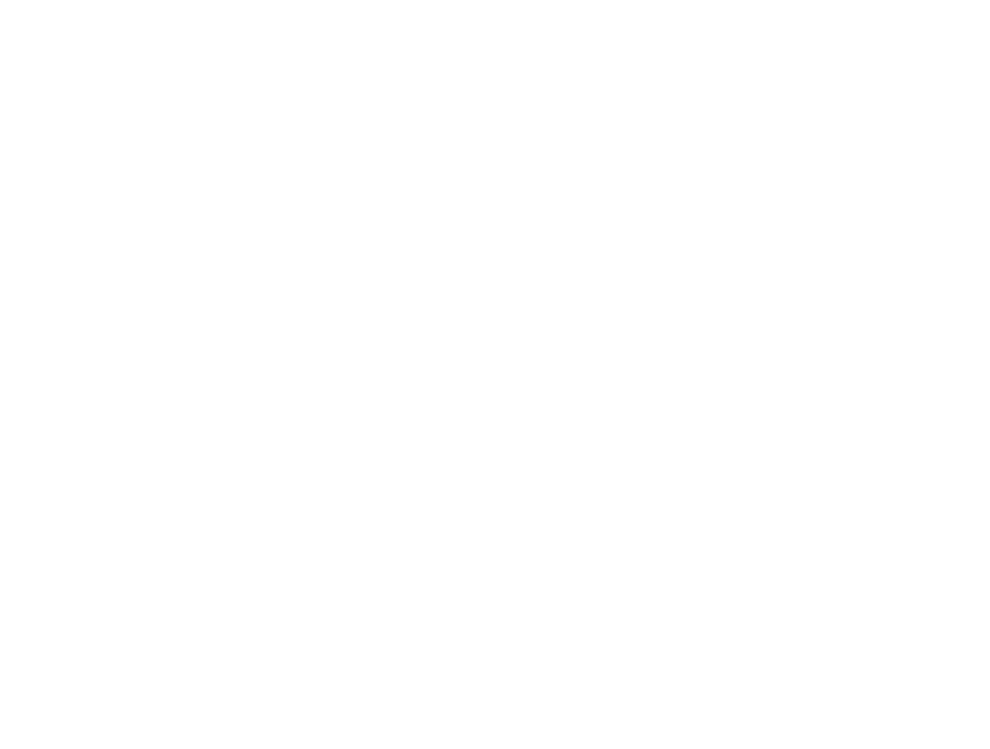

In [0]:
# ── Cell 7: Playoff Elevators and Shrinkers ──

rs_df = agg[agg["Season Type"] == "Regular Season"][[
    "playerName", "Role Classification", "Position",
    "Scoring Percentile", "Rebounding Percentile", "Playmaking Percentile"
]].copy()

po_df = agg[agg["Season Type"] == "Playoffs"][[
    "playerName",
    "Scoring Percentile", "Rebounding Percentile", "Playmaking Percentile"
]].copy()

delta = rs_df.merge(po_df, on="playerName", suffixes=("_RS", "_PO"))
delta["Scoring Delta"]    = (delta["Scoring Percentile_PO"]    - delta["Scoring Percentile_RS"]).round(1)
delta["Rebounding Delta"] = (delta["Rebounding Percentile_PO"] - delta["Rebounding Percentile_RS"]).round(1)
delta["Playmaking Delta"] = (delta["Playmaking Percentile_PO"] - delta["Playmaking Percentile_RS"]).round(1)

delta = delta.dropna(subset=["Scoring Percentile_PO"])

view_cols = ["playerName", "Role Classification",
             "Scoring Percentile_RS", "Scoring Percentile_PO", "Scoring Delta"]

print("═" * 65)
print("TOP 15 PLAYOFF ELEVATORS (Scoring Percentile)")
print("═" * 65)
display(spark.createDataFrame(delta.nlargest(15, "Scoring Delta")[view_cols]))

print("═" * 65)
print("TOP 15 PLAYOFF SHRINKERS (Scoring Percentile)")
print("═" * 65)
display(spark.createDataFrame(delta.nsmallest(15, "Scoring Delta")[view_cols]))


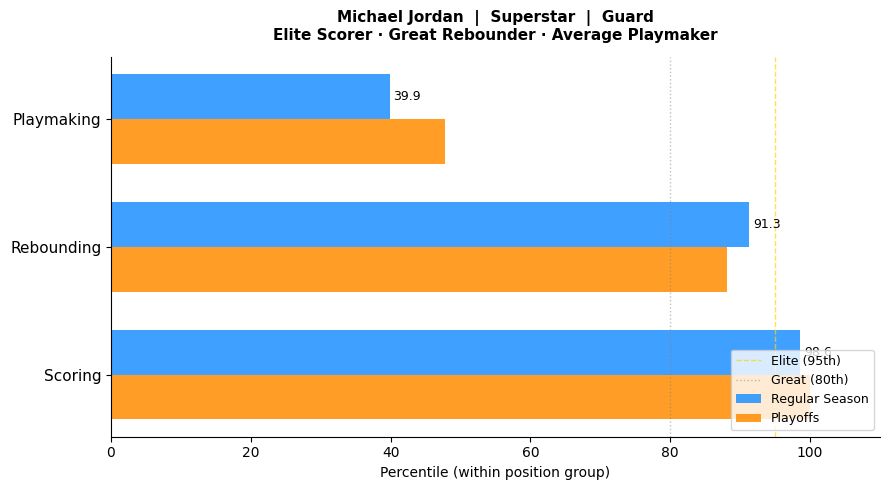

⬇ Download chart: player_skill_profile.png
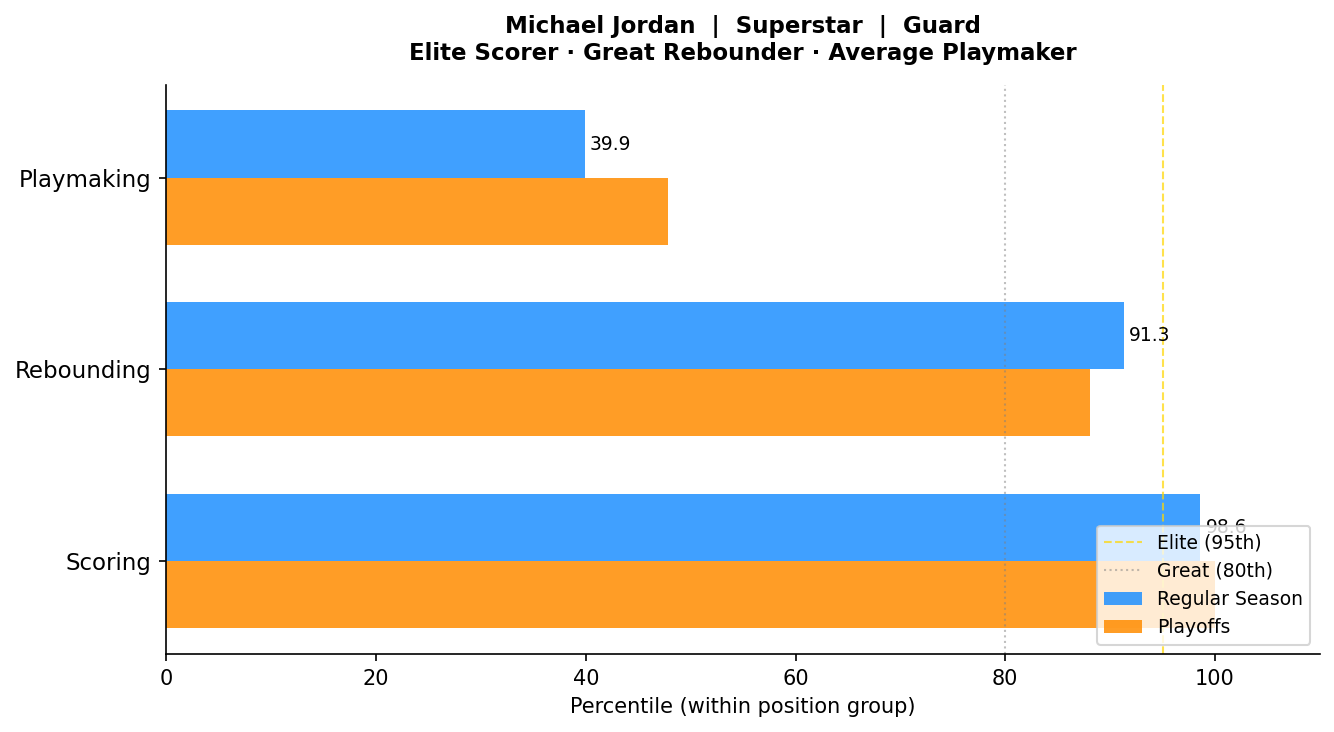

In [0]:
# ── Cell 8: Player Skill Profile ──

import matplotlib.pyplot as plt
import numpy as np
import base64
import io

# ── Change this to look up any player ──
PLAYER_NAME = "Michael Jordan"

player_data = agg[agg["playerName"] == PLAYER_NAME]

if player_data.empty:
    print(f"Player '{PLAYER_NAME}' not found.")
else:
    rs_row = player_data[player_data["Season Type"] == "Regular Season"].iloc[0]
    po_row = player_data[player_data["Season Type"] == "Playoffs"]

    skills  = ["Scoring", "Rebounding", "Playmaking"]
    rs_vals = [
        rs_row["Scoring Percentile"],
        rs_row["Rebounding Percentile"],
        rs_row["Playmaking Percentile"]
    ]
    po_vals = (
        [
            po_row["Scoring Percentile"].values[0],
            po_row["Rebounding Percentile"].values[0],
            po_row["Playmaking Percentile"].values[0]
        ]
        if not po_row.empty else [None, None, None]
    )

    x     = np.arange(len(skills))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(x + width/2, rs_vals, width, label="Regular Season",
            color="#1E90FF", alpha=0.85)
    if any(v is not None for v in po_vals):
        ax.barh(x - width/2, po_vals, width, label="Playoffs",
                color="#FF8C00", alpha=0.85)

    for i, val in enumerate(rs_vals):
        if val and not np.isnan(val):
            ax.text(val + 0.5, i + width/2, f"{val:.1f}",
                    va="center", fontsize=9)

    ax.set_yticks(x)
    ax.set_yticklabels(skills, fontsize=11)
    ax.set_xlim(0, 110)
    ax.set_xlabel("Percentile (within position group)", fontsize=10)
    ax.set_title(
        f"{PLAYER_NAME}  |  {rs_row['Role Classification']}  |  {rs_row['Position']}\n"
        f"{rs_row['Scoring Label']} \u00b7 {rs_row['Rebounding Label']} \u00b7 {rs_row['Playmaking Label']}",
        fontsize=11, fontweight="bold", pad=12
    )
    ax.axvline(x=95, color="gold",  linestyle="--", linewidth=1, alpha=0.7, label="Elite (95th)")
    ax.axvline(x=80, color="gray",  linestyle=":",  linewidth=1, alpha=0.5, label="Great (80th)")
    ax.legend(fontsize=9, loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()

    # ── Save to buffer and render download button ──
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode()
    plt.show()

    displayHTML(f'''
      <a href="data:image/png;base64,{b64}"
         download="player_skill_profile.png"
         style="display:inline-block; margin-top:10px; padding:8px 16px;
                background:#1d428a; color:white; border-radius:4px;
                text-decoration:none; font-family:sans-serif;">
        \u2b07 Download chart: player_skill_profile.png
      </a>
    ''')
